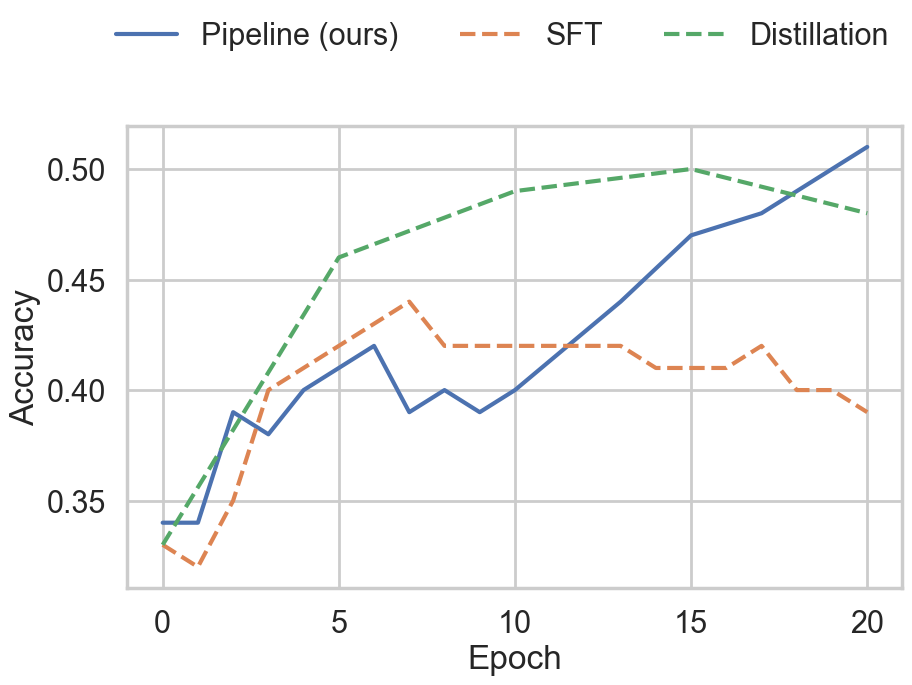

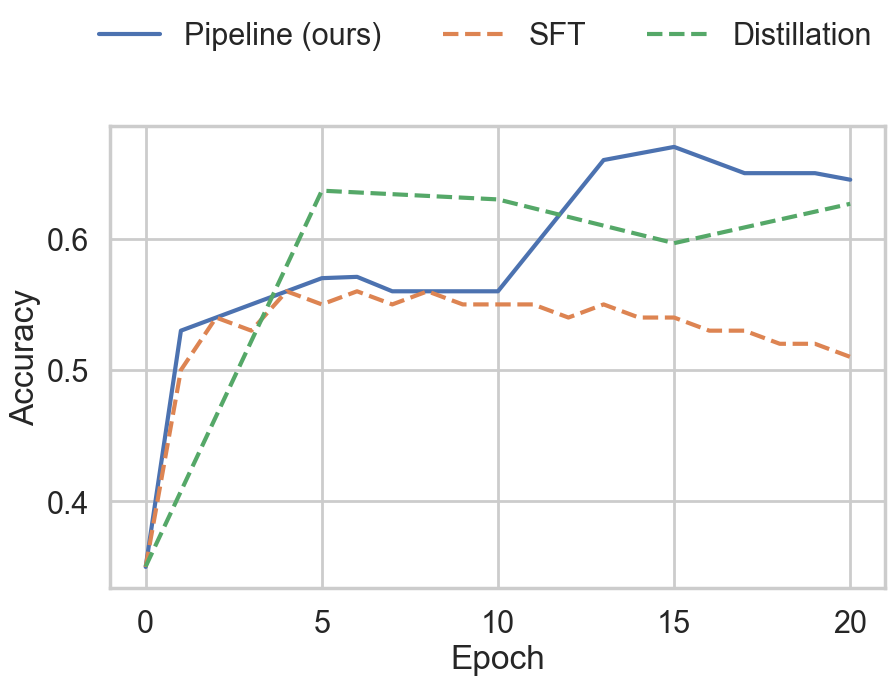

In [12]:
import json

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.interpolate import interp1d

sns.set_theme(palette="deep")
sns.set_style("whitegrid")
sns.set_context("poster")

epochs = np.linspace(0, 20, 21)


def interpolate_missing_epochs(epochs_list, accuracy_list, target_epochs=None):
    """
    Interpolate missing epoch values to create a complete sequence from 0 to 20.

    Args:
        epochs_list: List of epoch values (may have gaps)
        accuracy_list: List of corresponding accuracy values
        target_epochs: Target epoch sequence (default: 0 to 20)

    Returns:
        Tuple of (complete_epochs, interpolated_accuracies)
    """
    if target_epochs is None:
        target_epochs = np.arange(0, 21)

    # Convert to numpy arrays for easier manipulation
    epochs_array = np.array(epochs_list)
    accuracy_array = np.array(accuracy_list)

    # Sort by epochs to ensure proper interpolation
    sort_idx = np.argsort(epochs_array)
    epochs_array = epochs_array[sort_idx]
    accuracy_array = accuracy_array[sort_idx]

    # Remove duplicate epochs by averaging accuracy values
    unique_epochs = []
    unique_accuracies = []

    i = 0
    while i < len(epochs_array):
        current_epoch = epochs_array[i]
        current_accuracies = [accuracy_array[i]]

        # Collect all accuracies for the same epoch
        j = i + 1
        while j < len(epochs_array) and epochs_array[j] == current_epoch:
            current_accuracies.append(accuracy_array[j])
            j += 1

        unique_epochs.append(current_epoch)
        unique_accuracies.append(np.mean(current_accuracies))
        i = j

    unique_epochs = np.array(unique_epochs)
    unique_accuracies = np.array(unique_accuracies)

    # If we have enough points for interpolation
    if len(unique_epochs) > 1:
        # Create interpolation function with bounds to prevent unrealistic extrapolation
        f = interp1d(
            unique_epochs,
            unique_accuracies,
            kind="linear",
            bounds_error=False,
            fill_value=(unique_accuracies[0], unique_accuracies[-1]),
        )

        # Interpolate for all target epochs
        interpolated_accuracies = f(target_epochs)
    else:
        # If only one point, use constant value
        interpolated_accuracies = np.full_like(target_epochs, unique_accuracies[0], dtype=float)

    return target_epochs.tolist(), interpolated_accuracies.tolist()


def load_jsonl_results(paths: list[str]):
    results = []
    for path in paths:
        # Calculate offset as the next epoch after the last one we have
        offset = results[-1]["epoch"] + 1 if results else 0

        with open(path, "r") as f:
            pt_results: list[dict] = [json.loads(line) for line in f]
            pt_results = [item for item in pt_results if item["desc"] == "test_balanced"]

            pt_results = [{"accuracy": item["accuracy"], "epoch": item["epoch"] + offset} for item in pt_results]
            results += pt_results

    epochs_list = [item["epoch"] for item in results]
    accuracy_list = [item["accuracy"] for item in results]

    # Interpolate missing values
    return interpolate_missing_epochs(epochs_list, accuracy_list)


qwen_pipeline = load_jsonl_results(
    [
        "../../../artifacts/pipeline_20epochs/pipeline/qwen/pt1/training_38379_results.jsonl",
        "../../../artifacts/pipeline_20epochs/pipeline/qwen/pt2/training_2438_results.jsonl",
    ]
)
qwen_full_sft = load_jsonl_results(
    [
        "../../../artifacts/pipeline_20epochs/sft_baseline/qwen/training_891_results.jsonl",
    ]
)
qwen_full_distill = load_jsonl_results(
    [
        "../../../artifacts/pipeline_20epochs/full_distill_baseline/qwen/training_369_results.jsonl",
    ]
)

phi_pipeline = load_jsonl_results(
    [
        "../../../artifacts/pipeline_20epochs/pipeline/phi4/pt1/training_37578_results.jsonl",
        "../../../artifacts/pipeline_20epochs/pipeline/phi4/pt2/training_98392_results.jsonl",
    ]
)
phi_full_sft = load_jsonl_results(
    [
        "../../../artifacts/pipeline_20epochs/sft_baseline/phi4/training_1425_results.jsonl",
    ]
)
phi_full_distill = load_jsonl_results(
    [
        "../../../artifacts/pipeline_20epochs/full_distill_baseline/phi4/training_3308_results.jsonl",
    ]
)

fig = plt.figure(figsize=(10, 6))

plt.plot(qwen_pipeline[0], qwen_pipeline[1], label="Pipeline (ours)")
plt.plot(qwen_full_sft[0], qwen_full_sft[1], label="SFT", linestyle="dashed")
plt.plot(qwen_full_distill[0], qwen_full_distill[1], label="Distillation", linestyle="dashed")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

fig.legend(loc="outside upper center", bbox_to_anchor=(0.5, 1.1), ncol=3, frameon=False)
plt.savefig("../../../artifacts/pipeline/qwen_pipeline_20epochs.pdf", bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(10, 6))

plt.plot(phi_pipeline[0], phi_pipeline[1], label="Pipeline (ours)")
plt.plot(phi_full_sft[0], phi_full_sft[1], label="SFT", linestyle="dashed")
plt.plot(phi_full_distill[0], phi_full_distill[1], label="Distillation", linestyle="dashed")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

fig.legend(loc="outside upper center", bbox_to_anchor=(0.5, 1.1), ncol=3, frameon=False)
plt.savefig("../../../artifacts/pipeline/phi_pipeline_20epochs.pdf", bbox_inches="tight")
plt.show()